# Prompt Optimization Tool

## Background
Before joining this course, I heard a lot of sceptical notion about Prompt Engineering. It's seen as something too shallow to be called as "engineering". But after joining the course, knowing how useful Prompt Engineering has helped LLM development until now, I want to help people to understand how to make their prompt better so they can utilize LLM more efficiently.

## Video Explanation

## Skip into this part to see the DEMO
[DEMO](https://www.kaggle.com/code/faisaladiprabowo/prompt-optimization-tool/edit#Prompt-Optimizer-Tool)

## How it works?
1. System Preparation : The system will store several prompting method.
2. User Input : User will give what is the objective that they want to achieve with their prompt.
3. System Processing : System will retrieve several alternatives, based on user's input.
4. System Evaluation : System will check from all options, which one is the most effective to answer user's objective.
5. User Feedback : User will choose which alternative is the best and give scoring to the prompt result.

## This tools includes several LLM Capabilities:
- Structured output/JSON mode/controlled generation
- Few-shot prompting ✅
- Document understanding
- Image understanding
- Video understanding
- Audio understanding
- Function Calling
- Agents
- Long context window
- Context caching
- Gen AI evaluation ✅
- Grounding
- Embeddings ✅
- Retrieval augmented generation (RAG) ✅
- Vector search/vector store/vector database
- MLOps (with GenAI)

# Setting-up Notebook
Please ignore warning

In [1]:
!pip uninstall -qy jupyterlab kfp # Remove unused packages from Kaggle's base image that conflict
!pip install -U -q "google-genai"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-lsp 3.10.2 requires jupyterlab<4.0.0a0,>=3.1.0, which is not installed.


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from google.api_core import retry
import tqdm
from tqdm.rich import tqdm as tqdmr
import warnings
from datetime import datetime

# Configuration and Setup
warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)
tqdmr.pandas()  # Add tqdm to Pandas

/kaggle/input/prompt-optimizer-dataset.txt


In [3]:
from google import genai
from google.genai import types

genai.__version__

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GOOGLE_API_KEY = user_secrets.get_secret("GOOGLE_API_KEY")

client = genai.Client(api_key=GOOGLE_API_KEY)

if GOOGLE_API_KEY and len(GOOGLE_API_KEY.strip()) > 0:
    client = genai.Client(api_key=GOOGLE_API_KEY)
    print("API Key loaded")
else:
    print("Error: Google API Key not found or invalid")

API Key loaded


In [4]:
from google.api_core import retry

# Retry logic for API calls
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

genai.models.Models.generate_content = retry.Retry(
    predicate=is_retriable)(genai.models.Models.generate_content)

# Setting-up Functions & Logics

## Load Reference Data
Reference dataset is an example of popular and validated prompt from various use cases. 
This list is currently AI generated, but the purpose it to showcase the capability of retrieving best practice prompts with the performance quality. 
This list can later be expanded as needed and will have a richer data when more prompts are stored from this tool.

In this dataset, prompts are categorized in several prompting classification (Oluwole Fagbohun, 2023)
<div>
    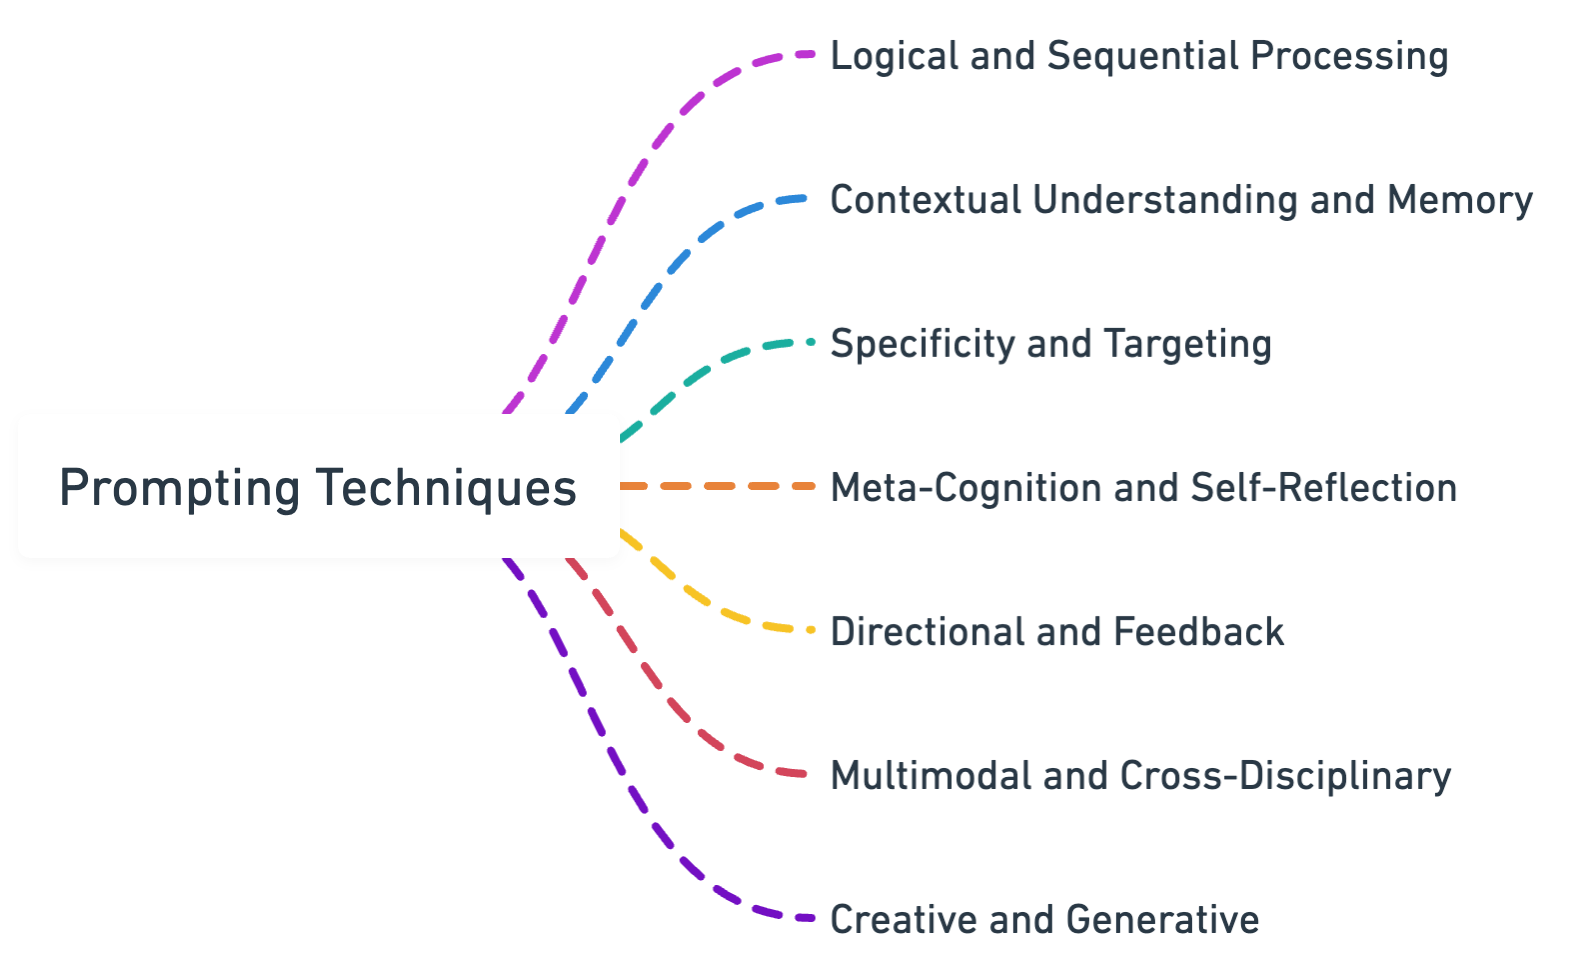
</div>
Source : 

[Oluwole Fagbohun, 2023](https://arxiv.org/html/2402.14837v1)

Prompt Optimizer Dataset Example:
```
{
    "id": "prompt-20250413-001",
    "user_prompt": "generate instagram content for travel to Korea",
    "objective": ["creativity", "accuracy"],
    "text_for_embedding": "generate creative instagram content travel Korea social media tourism with valid results",
    "type_analysis": {
      "intent": ["user_prompt"],
      "classification": ["creative_generative", "specifity_targeting"],
      "prompt_technique": ["one-shot-prompt"],
      "prompt_structure": ["role", "context"],
      "model": ["gemini-2.0-flash"],
      "features": ["web-search"],
      "parameters": {
        "temperature": 0.8,
        "top_p": 0.95
      }
    },
    "proposed_prompt": "As a travel content creator specializing in Korean tourism, craft 5 engaging Instagram posts that showcase unique cultural experiences, hidden gems, and photogenic locations across South Korea. For each post, include a captivating caption (up to 150 characters), relevant hashtags, and suggest the best time of day for photography. Focus on authentic experiences that go beyond typical tourist attractions.",
    "evaluation": {
      "system_evaluation": {
        "total_token": 340,
        "cost": 0.85,
        "creativity": 0.9
      },
      "user_evaluation": {
        "satisfaction": 0.95
      }
    }
  },
```

Properties in the dataset:
- intent = user prompt, system prompt, invalid (prompt injection or invalid requests)
- classification = logical_sequential,contextual_memory,specifity_targeting,meta_cognition,directional_feedback,multimodal,creative_generative (based on classification above)
- prompt_technique = chain-of-thought, socratic, one-shot-prompt, few-shot-prompt, zero-shot-prompt, reAct-prompt
- prompt_structure = context, problem, data input, documentation, detail, definition, role, task, tools reference, instruction, format, purpose, analogy, steps, expectation, example, preferences, requirement, next steps, constraints

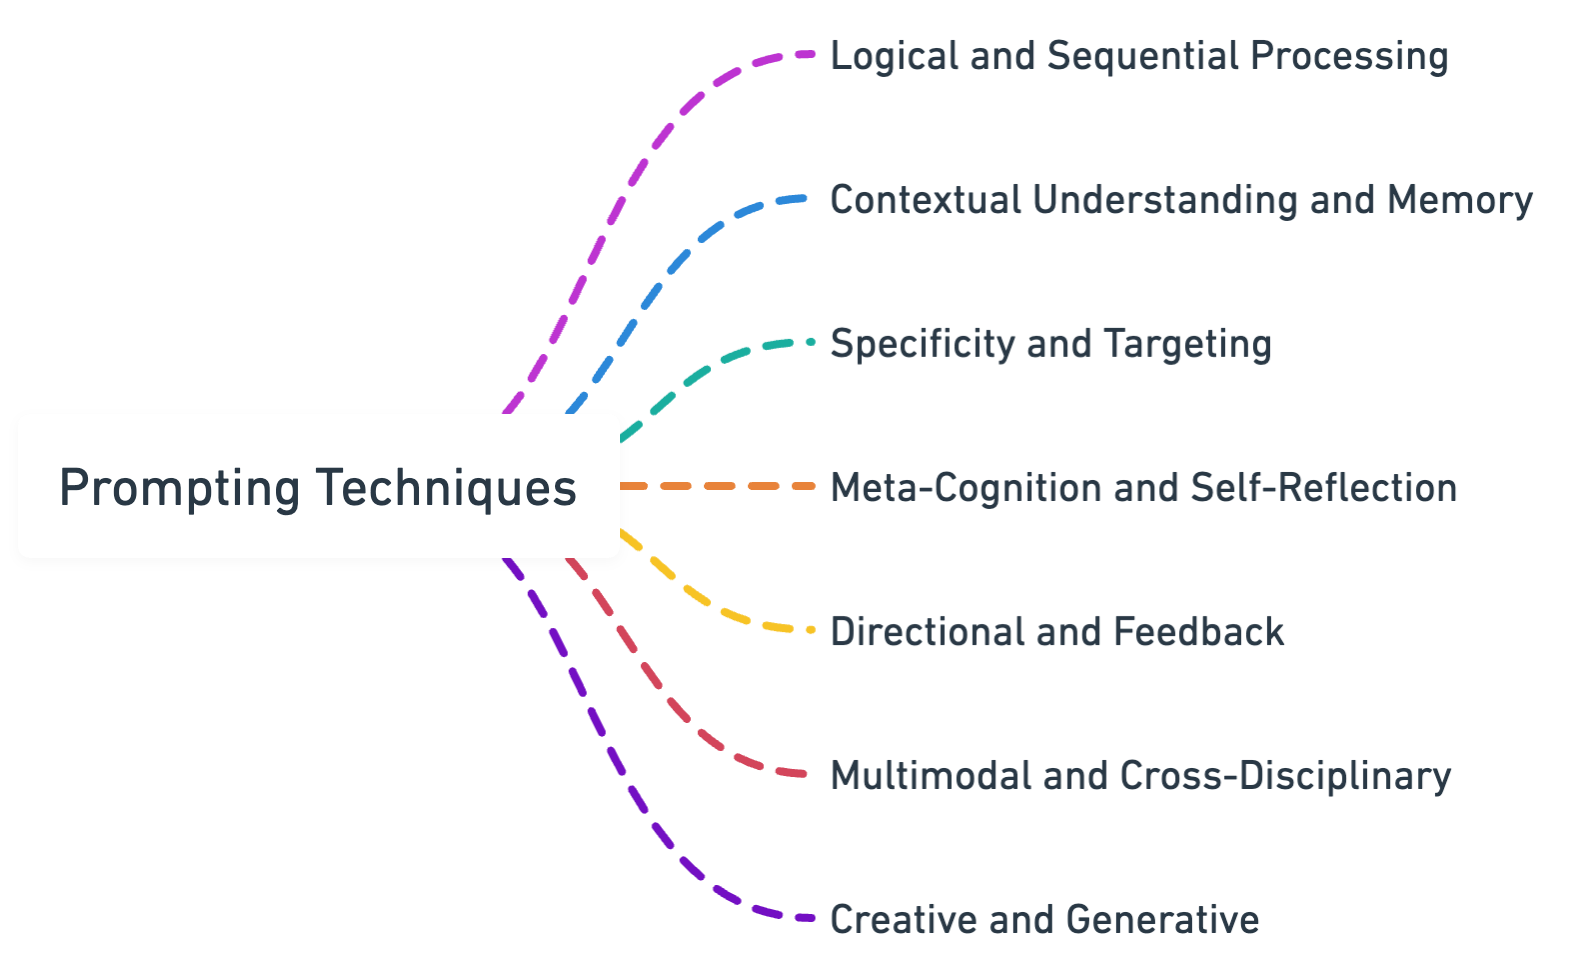

In [5]:
# Function to load and parse the prompt dataset
def load_prompt_dataset(file_path):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        print(f"✅ Successfully loaded {len(data)} prompt examples from the dataset.")
        return data
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return []

# Load the dataset from Kaggle input path
dataset_path = "/kaggle/input/prompt-optimizer-dataset.txt"
prompt_data = load_prompt_dataset(dataset_path)

# Display dataset statistics
print(f"\nDataset contains {len(prompt_data)} prompt examples")

# Display dataset statistics
print(f"\nDataset contains {len(prompt_data)} prompt examples")

# Analyze the prompt objectives in our dataset
all_objectives = [obj for item in prompt_data for obj in item.get("objective", [])]
unique_objectives = set(all_objectives)
objective_counts = {obj: all_objectives.count(obj) for obj in unique_objectives}

print("\nObjectives available in our dataset:")
for obj, count in sorted(objective_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"- {obj}: {count} examples")

# Preview a sample entry
print("\nSample entry from the dataset:")
sample = prompt_data[0]
print(f"User prompt: \"{sample['user_prompt']}\"")
print(f"Objectives: {sample['objective']}")
print(f"Optimized prompt: \"{sample['proposed_prompt']}\"")

✅ Successfully loaded 26 prompt examples from the dataset.

Dataset contains 26 prompt examples

Dataset contains 26 prompt examples

Objectives available in our dataset:
- clarity: 6 examples
- accuracy: 5 examples
- personalization: 4 examples
- practicality: 4 examples
- creativity: 4 examples
- educational: 3 examples
- practical: 3 examples
- comprehensiveness: 3 examples
- thoroughness: 2 examples
- persuasiveness: 2 examples
- helpfulness: 2 examples
- effectiveness: 1 examples
- functionality: 1 examples
- scientific accuracy: 1 examples
- actionability: 1 examples
- professionalism: 1 examples
- specificity: 1 examples
- simplicity: 1 examples
- depth: 1 examples
- insight: 1 examples
- comprehensive: 1 examples
- accessibility: 1 examples
- age-appropriateness: 1 examples
- engagement: 1 examples
- emotional impact: 1 examples

Sample entry from the dataset:
User prompt: "generate instagram content for travel to Korea"
Objectives: ['creativity', 'accuracy']
Optimized prompt: 

## Embedding Dataset into Vector Data

In [6]:
## 🔍 Embedding Creation and Semantic Search
# Define retry logic for API calls
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

# Enhanced embedding function with proper task type for retrieval
@retry.Retry(predicate=is_retriable, timeout=300.0)
def embed_content(text, task_type="RETRIEVAL_DOCUMENT"):
    """
    Embed content with the specified task type.
    Use RETRIEVAL_DOCUMENT for indexing documents/prompts
    Use RETRIEVAL_QUERY for user queries to find matches
    """
    try:
        response = client.models.embed_content(
            model="models/text-embedding-004",
            contents=text,
            config=types.EmbedContentConfig(
                task_type=task_type,
        ),
        )
        # return response.embedding
        return response.embeddings[0].values
    except Exception as e:
        print(f"Embedding error: {e}")
        # Return a zero vector as fallback (embedding dimension for text-embedding-005 is 768)
        return [0] * 768

def create_prompt_embeddings(data):
    """Create embeddings for all prompts in the dataset"""
    print("📊 Creating embeddings for prompt examples...")
    embeddings_data = []
    
    for item in tqdm.tqdm(data):
        # Use the text_for_embedding field if available, otherwise use user_prompt
        embedding_text = item.get("text_for_embedding", item.get("user_prompt", ""))
        
        # Get embedding with RETRIEVAL_DOCUMENT task type for indexing
        embedding = embed_content(embedding_text, task_type="RETRIEVAL_DOCUMENT")
        
        embeddings_data.append({
            "id": item["id"],
            "user_prompt": item["user_prompt"],
            "proposed_prompt": item["proposed_prompt"],
            "text_for_embedding": embedding_text,
            "objective": item.get("objective", []),
            "type_analysis": item.get("type_analysis", {}),
            "embedding": embedding
        })
    
    print(f"✅ Created embeddings for {len(embeddings_data)} prompt examples.")
    return embeddings_data

# Create embeddings for our prompt database
prompt_embeddings = create_prompt_embeddings(prompt_data)

📊 Creating embeddings for prompt examples...


100%|██████████| 26/26 [00:08<00:00,  3.11it/s]

✅ Created embeddings for 26 prompt examples.


## Logic for finding similarity between user's query with dataset

In [7]:
def find_similar_prompts_advanced(user_prompt, user_objectives, prompt_embeddings, similarity_threshold=0.5, top_n=5):
    """Find the most similar prompts to the user's input with advanced ranking"""
    # Embed the user prompt with RETRIEVAL_QUERY task type
    user_embedding = embed_content(user_prompt, task_type="RETRIEVAL_QUERY")
    
    # Calculate similarities with all stored prompts
    candidates = []
    for item in prompt_embeddings:
        # Calculate cosine similarity
        similarity = cosine_similarity([user_embedding], [item["embedding"]])[0][0]
        
        # Only consider candidates above threshold
        if similarity < similarity_threshold:
            continue
            
        # Get evaluation metrics with defaults if not present
        satisfaction = item.get("evaluation", {}).get("user_evaluation", {}).get("satisfaction", 0.5)
        system_eval = item.get("evaluation", {}).get("system_evaluation", {})
        token_count = system_eval.get("total_token", 300)
        cost = system_eval.get("cost", 0.5)
        
        # Check if the item has any matching objectives with user objectives
        objective_match_score = 0
        if user_objectives and item.get("objective"):
            matching_objectives = set(user_objectives).intersection(set(item["objective"]))
            objective_match_score = len(matching_objectives) / max(len(user_objectives), 1)
        
        # Calculate the combined score
        # 40% similarity + 30% satisfaction + 15% objective match + 15% cost efficiency
        cost_efficiency = 1.0 - min(cost / 2.0, 1.0)  # Lower cost is better
        combined_score = (
            0.40 * similarity + 
            0.30 * satisfaction + 
            0.15 * objective_match_score + 
            0.15 * cost_efficiency
        )
        
        candidates.append({
            "id": item["id"],
            "user_prompt": item["user_prompt"],
            "proposed_prompt": item["proposed_prompt"],
            "similarity": similarity,
            "satisfaction": satisfaction,
            "objective_match": objective_match_score,
            "cost_efficiency": cost_efficiency,
            "combined_score": combined_score,
            "objective": item["objective"],
            "type_analysis": item.get("type_analysis", {}),
            "evaluation": item.get("evaluation", {})
        })
    
    # Sort by combined score and get top N
    sorted_candidates = sorted(candidates, key=lambda x: x["combined_score"], reverse=True)
    return sorted_candidates[:top_n]

def display_similar_prompts_advanced(similar_prompts):
    """Display the similar prompts with detailed scoring"""
    print("\n🔍 Top similar prompts in our database:")
    
    for i, item in enumerate(similar_prompts):
        sim_percentage = f"{item['similarity'] * 100:.1f}%"
        combined_score = f"{item['combined_score'] * 100:.1f}%"
        satisfaction = f"{item['satisfaction'] * 100:.1f}%"
        objective_match = f"{item['objective_match'] * 100:.1f}%"
        
        print(f"\n{i+1}. Similar prompt (Combined score: {combined_score}):")
        print(f"   Similarity: {sim_percentage} | Satisfaction: {satisfaction} | Objective match: {objective_match}")
        print(f"   Original request: \"{item['user_prompt']}\"")
        print(f"   Optimized version: \"{item['proposed_prompt']}\"")
        print(f"   Objectives: {', '.join(item['objective'])}")
        
        # Display type analysis if available
        if item.get("type_analysis"):
            type_analysis = item["type_analysis"]
            print(f"   Prompt technique: {', '.join(type_analysis.get('prompt_technique', ['N/A']))}")
            print(f"   Classification: {', '.join(type_analysis.get('classification', ['N/A']))}")
            
            # Display parameters if available
            params = type_analysis.get("parameters", {})
            if params:
                print(f"   Parameters: Temperature={params.get('temperature', 'N/A')}, Top-p={params.get('top_p', 'N/A')}")
    
    return similar_prompts[0] if similar_prompts else None

def visualize_similarity_advanced(similar_prompts):
    """Visualize the similarity scores and other metrics of the prompts"""
    if not similar_prompts or len(similar_prompts) == 0:
        print("No similar prompts to visualize.")
        return
    
    # Prepare data for visualization
    labels = [f"Example {i+1}" for i in range(len(similar_prompts))]
    similarity_scores = [item["similarity"] for item in similar_prompts]
    satisfaction_scores = [item["satisfaction"] for item in similar_prompts]
    objective_match_scores = [item["objective_match"] for item in similar_prompts]
    combined_scores = [item["combined_score"] for item in similar_prompts]
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Similarity scores
    bars1 = axes[0, 0].bar(labels, similarity_scores, color=sns.color_palette("viridis", len(similarity_scores)))
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].set_ylabel("Similarity Score")
    axes[0, 0].set_title("Semantic Similarity")
    for bar in bars1:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom')
    
    # Satisfaction scores
    bars2 = axes[0, 1].bar(labels, satisfaction_scores, color=sns.color_palette("mako", len(satisfaction_scores)))
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].set_ylabel("User Satisfaction")
    axes[0, 1].set_title("Previous User Satisfaction")
    for bar in bars2:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom')
    
    # Objective match scores
    bars3 = axes[1, 0].bar(labels, objective_match_scores, color=sns.color_palette("flare", len(objective_match_scores)))
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_ylabel("Objective Match")
    axes[1, 0].set_title("Objective Alignment")
    for bar in bars3:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom')
    
    # Combined scores
    bars4 = axes[1, 1].bar(labels, combined_scores, color=sns.color_palette("rocket", len(combined_scores)))
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_ylabel("Combined Score")
    axes[1, 1].set_title("Overall Ranking Score")
    for bar in bars4:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    return fig


## Method for Prompt Evaluation
Prompt Evaluation Method including:
1. Token Efficiency (lower is better)
2. Instruction Clarity (via embedding similarity to clear instruction patterns)
3. Response Relevance (embedding similarity between prompt intent and response)
4. Structure Adherence (if user wanted structured output)
5. Creativity (if user wanted creative outputs)
6. Calculate weighted score

In [8]:
def evaluate_prompt(original_prompt, optimized_prompt, user_objectives):
    """
    Evaluate the quality of an optimized prompt based on multiple dimensions
    
    Parameters:
    - original_prompt: User's initial description or prompt
    - optimized_prompt: Generated optimized prompt
    - user_objectives: List of user's stated objectives
    
    Returns:
    - Dictionary of scores across different dimensions
    """
    scores = {}
    
    # 1. Token Efficiency (lower is better)
    original_tokens = len(original_prompt.split())
    optimized_tokens = len(optimized_prompt.split())
    token_ratio = optimized_tokens / max(original_tokens, 1)
    # Normalize: Lower is better, but we want higher scores to be better
    scores['token_efficiency'] = max(0, 1 - (token_ratio - 1) / 3)  # Cap at 0
    
    # 2. Instruction Clarity - Check for clear instruction patterns
    clear_instructions = [
        "please provide", "your task is to", "i need you to", 
        "generate a", "create a", "analyze the following"
    ]
    instruction_score = 0
    optimized_lower = optimized_prompt.lower()
    for phrase in clear_instructions:
        if phrase in optimized_lower:
            instruction_score += 0.2
    scores['instruction_clarity'] = min(1.0, instruction_score)
    
    # 3. Specificity Score - Check for specific details and requirements
    specificity_indicators = ["specifically", "in detail", "step by step", "following format", 
                             "include", "ensure", "must have", "example"]
    specificity_score = 0
    for indicator in specificity_indicators:
        if indicator in optimized_lower:
            specificity_score += 0.15
    scores['specificity'] = min(1.0, specificity_score)
    
    # 4. Structure Adherence 
    structure_terms = ["json", "table", "list", "format", "structure", "step", "bullet", "numbered"]
    structure_indicators = ["{", "}", "[", "]", ":", "- ", "1. ", "2. ", "Step 1", "First"]
    
    structure_score = 0
    for term in structure_terms:
        if term in optimized_lower:
            structure_score += 0.1
    
    for indicator in structure_indicators:
        if indicator in optimized_prompt:
            structure_score += 0.1
    
    scores['structure_adherence'] = min(1.0, structure_score)
    
    # 5. Creativity score
    creative_indicators = ["innovative", "creative", "unique", "original", "imagine", 
                          "beyond", "unusual", "novel", "engaging", "interesting"]
    creativity_score = 0
    for indicator in creative_indicators:
        if indicator in optimized_lower:
            creativity_score += 0.15
    
    # Also consider prompt length as a proxy for detail and creativity
    if len(optimized_prompt.split()) > 100:
        creativity_score += 0.2
    
    scores['creativity'] = min(1.0, creativity_score)
    
    # 6. Calculate estimated tokens and cost
    token_estimate = len(optimized_prompt.split()) * 1.3  # Rough estimate
    scores['total_token'] = int(token_estimate)
    scores['cost'] = token_estimate / 1000 * 0.002 * 1000  # Simplified cost calculation (assuming 0.002 per 1K tokens)
    
    # 7. Calculate objective-specific scores based on user objectives
    if user_objectives:
        for objective in user_objectives:
            objective_lower = objective.lower()
            if 'clarity' in objective_lower:
                scores['clarity'] = scores['instruction_clarity']
            elif 'specific' in objective_lower:
                scores['specificity'] = scores['specificity']
            elif 'creativ' in objective_lower:
                scores['creativity'] = scores['creativity']
            elif 'comprehensive' in objective_lower or 'thorough' in objective_lower:
                comprehensiveness = min(1.0, len(optimized_prompt.split()) / 200)
                scores['comprehensiveness'] = comprehensiveness
            elif 'brief' in objective_lower or 'concise' in objective_lower:
                conciseness = max(0, 1 - len(optimized_prompt.split()) / 200)
                scores['conciseness'] = conciseness
    
    # Calculate weighted overall score based on user objectives
    weights = {
        'token_efficiency': 1.0,
        'instruction_clarity': 1.0,
        'specificity': 1.0,
        'structure_adherence': 0.8,
        'creativity': 0.8
    }
    
    # Adjust weights based on user objectives
    if user_objectives:
        for objective in user_objectives:
            objective_lower = objective.lower()
            if 'cost' in objective_lower or 'token' in objective_lower or 'efficiency' in objective_lower:
                weights['token_efficiency'] = 2.0
            if 'clarity' in objective_lower or 'clear' in objective_lower:
                weights['instruction_clarity'] = 2.0
            if 'creativ' in objective_lower:
                weights['creativity'] = 2.0
            if 'specific' in objective_lower:
                weights['specificity'] = 2.0
            if 'structure' in objective_lower or 'format' in objective_lower:
                weights['structure_adherence'] = 2.0
    
    # Calculate relevant scores for overall
    relevant_scores = {k: v for k, v in scores.items() 
                      if k in weights and isinstance(v, (int, float))}
    
    # Calculate weighted average
    if relevant_scores:
        relevant_weights = {k: weights[k] for k in relevant_scores.keys()}
        weighted_sum = sum(score * relevant_weights[metric] for metric, score in relevant_scores.items())
        total_weight = sum(relevant_weights.values())
        scores['overall'] = weighted_sum / total_weight
    else:
        scores['overall'] = 0.5  # Default
    
    return scores


## Logic for prompt generation

In [9]:
def generate_optimized_prompt_alternatives(user_prompt, user_objectives, similar_prompts=None):
    """Generate multiple optimized prompt alternatives based on different approaches"""
    
    # Prepare common system prompt parts
    system_prompt_base = """
    You are an expert prompt engineer who creates optimized prompts for AI models. 
    Your task is to create enhanced, well-structured prompts that will produce better results.
    """
    
    alternatives = []
    
    # ALTERNATIVE 1: Based on similarity matches
    if similar_prompts and len(similar_prompts) > 0:
        # Get the type analysis from the best match
        best_match = similar_prompts[0]
        match_type_analysis = best_match.get("type_analysis", {})
        
        # Create system prompt for similarity-based alternative
        system_prompt_similarity = system_prompt_base + """
        Analyze the examples of similar prompts and their optimized versions. 
        Create an optimized prompt that follows similar patterns and incorporates the best elements from these examples.
        The optimized prompt should be specific, clear, and align with the stated objectives.
        In your response, include a detailed type analysis of your proposed prompt.
        """
        
        # Prepare examples from similar prompts
        examples_text = "Here are examples of optimized prompts for similar requests:\n\n"
        for i, item in enumerate(similar_prompts[:3]):  # Use top 3 similar prompts as examples
            examples_text += f"Original: \"{item['user_prompt']}\"\n"
            examples_text += f"Optimized: \"{item['proposed_prompt']}\"\n"
            # Include type analysis if available
            if item.get("type_analysis"):
                type_info = item["type_analysis"]
                examples_text += f"Classification: {type_info.get('classification', ['N/A'])}\n"
                examples_text += f"Technique: {type_info.get('prompt_technique', ['N/A'])}\n"
                examples_text += f"Structure: {type_info.get('prompt_structure', ['N/A'])}\n"
            examples_text += "\n"
        
        # Prepare user message
        objectives_text = ", ".join(user_objectives) if user_objectives else "effective, clear"
        user_message_similarity = f"""
        Please optimize this prompt: "{user_prompt}"
        
        My objectives are: {objectives_text}
        
        {examples_text}
        
        Create an optimized version that follows patterns from the examples and will produce better results.
        Provide a detailed type analysis of your proposed prompt in this format:
        
        OPTIMIZED PROMPT:
        [Your optimized prompt goes here]
        
        TYPE ANALYSIS:
        - Intent: [List appropriate intents]
        - Classification: [List appropriate classifications]
        - Prompt technique: [List appropriate techniques]
        - Prompt structure: [List appropriate structural elements]
        - Recommended model: [Suggest an appropriate model]
        - Features: [Suggest appropriate features]
        - Parameters: temperature=[value], top_p=[value]
        """
        
        try:       
            # Generate the similarity-based optimized prompt
            response = client.models.generate_content(
                model='gemini-2.0-flash',
                contents=user_message_similarity,
                config=types.GenerateContentConfig(
                    system_instruction=system_prompt_similarity,
                    temperature=0.7, 
                    top_p=0.95, 
                    top_k=40
                ),
            )
            
            response_text = response.text.strip()
            
            # Extract the optimized prompt and type analysis
            try:
                # Parse the response to extract optimized prompt and type analysis
                prompt_part = response_text.split("OPTIMIZED PROMPT:")[1].split("TYPE ANALYSIS:")[0].strip()
                type_analysis_text = response_text.split("TYPE ANALYSIS:")[1].strip()
                
                # Parse the type analysis
                type_analysis = {}
                for line in type_analysis_text.split("\n"):
                    line = line.strip()
                    if line.startswith("- Intent:"):
                        type_analysis["intent"] = [item.strip() for item in line.replace("- Intent:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Classification:"):
                        type_analysis["classification"] = [item.strip() for item in line.replace("- Classification:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Prompt technique:"):
                        type_analysis["prompt_technique"] = [item.strip() for item in line.replace("- Prompt technique:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Prompt structure:"):
                        type_analysis["prompt_structure"] = [item.strip() for item in line.replace("- Prompt structure:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Recommended model:"):
                        type_analysis["model"] = [item.strip() for item in line.replace("- Recommended model:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Features:"):
                        type_analysis["features"] = [item.strip() for item in line.replace("- Features:", "").strip().strip("[]").split(",")]
                    elif line.startswith("- Parameters:"):
                        params_text = line.replace("- Parameters:", "").strip()
                        params = {}
                        for param in params_text.split(","):
                            if "=" in param:
                                key, value = param.split("=")
                                try:
                                    params[key.strip()] = float(value.strip())
                                except:
                                    params[key.strip()] = value.strip()
                        type_analysis["parameters"] = params
                
                # Add the similarity-based alternative
                alternatives.append({
                    "id": "similarity-based",
                    "name": "Similarity-Based Optimization",
                    "description": "This prompt is optimized based on similar examples in our database.",
                    "prompt": prompt_part,
                    "type_analysis": type_analysis
                })
            except Exception as e:
                print(f"Error parsing similarity-based response: {e}")
                # Fallback: just use the whole response
                alternatives.append({
                    "id": "similarity-based",
                    "name": "Similarity-Based Optimization",
                    "description": "This prompt is optimized based on similar examples in our database.",
                    "prompt": response_text,
                    "type_analysis": match_type_analysis
                })
        except Exception as e:
            print(f"Error generating similarity-based optimized prompt: {e}")
    
    # ALTERNATIVE 2: Fresh creation based on LLM judgment
    # Create system prompt for fresh creation
    system_prompt_fresh = system_prompt_base + """
    Create a completely fresh, optimized prompt based on your expertise in prompt engineering.
    Do not rely on specific examples, but instead apply best practices for effective prompt design.
    The optimized prompt should be specific, clear, and align with the stated objectives.
    In your response, include a detailed type analysis of your proposed prompt.
    """
    
    # Prepare user message for fresh creation
    objectives_text = ", ".join(user_objectives) if user_objectives else "effective, clear"
    user_message_fresh = f"""
    Please optimize this prompt: "{user_prompt}"
    
    My objectives are: {objectives_text}
    
    Create a fresh, optimized version that applies best practices in prompt engineering to produce better results.
    
    Provide a detailed type analysis of your proposed prompt in this format:
    
    OPTIMIZED PROMPT:
    [Your optimized prompt goes here]
    
    TYPE ANALYSIS:
    - Intent: [List appropriate intents]
    - Classification: [List appropriate classifications]
    - Prompt technique: [List appropriate techniques]
    - Prompt structure: [List appropriate structural elements]
    - Recommended model: [Suggest an appropriate model]
    - Features: [Suggest appropriate features]
    - Parameters: temperature=[value], top_p=[value]
    """
    
    try:       
        # Generate the fresh optimized prompt
        response = client.models.generate_content(
            model='gemini-2.0-flash',
            contents=user_message_fresh,
            config=types.GenerateContentConfig(
                system_instruction=system_prompt_fresh,
                temperature=0.8,  # Slightly higher temperature for more creativity
                top_p=0.95, 
                top_k=40
            ),
        )
        
        response_text = response.text.strip()
        
        # Extract the optimized prompt and type analysis
        try:
            # Parse the response to extract optimized prompt and type analysis
            prompt_part = response_text.split("OPTIMIZED PROMPT:")[1].split("TYPE ANALYSIS:")[0].strip()
            type_analysis_text = response_text.split("TYPE ANALYSIS:")[1].strip()
            
            # Parse the type analysis
            type_analysis = {}
            for line in type_analysis_text.split("\n"):
                line = line.strip()
                if line.startswith("- Intent:"):
                    type_analysis["intent"] = [item.strip() for item in line.replace("- Intent:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Classification:"):
                    type_analysis["classification"] = [item.strip() for item in line.replace("- Classification:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Prompt technique:"):
                    type_analysis["prompt_technique"] = [item.strip() for item in line.replace("- Prompt technique:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Prompt structure:"):
                    type_analysis["prompt_structure"] = [item.strip() for item in line.replace("- Prompt structure:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Recommended model:"):
                    type_analysis["model"] = [item.strip() for item in line.replace("- Recommended model:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Features:"):
                    type_analysis["features"] = [item.strip() for item in line.replace("- Features:", "").strip().strip("[]").split(",")]
                elif line.startswith("- Parameters:"):
                    params_text = line.replace("- Parameters:", "").strip()
                    params = {}
                    for param in params_text.split(","):
                        if "=" in param:
                            key, value = param.split("=")
                            try:
                                params[key.strip()] = float(value.strip())
                            except:
                                params[key.strip()] = value.strip()
                    type_analysis["parameters"] = params
            
            # Add the fresh creation alternative
            alternatives.append({
                "id": "fresh-creation",
                "name": "Fresh Expert Creation",
                "description": "This prompt is freshly designed based on prompt engineering best practices.",
                "prompt": prompt_part,
                "type_analysis": type_analysis
            })
        except Exception as e:
            print(f"Error parsing fresh creation response: {e}")
            # Fallback: just use the whole response
            alternatives.append({
                "id": "fresh-creation",
                "name": "Fresh Expert Creation",
                "description": "This prompt is freshly designed based on prompt engineering best practices.",
                "prompt": response_text,
                "type_analysis": {}
            })
    except Exception as e:
        print(f"Error generating fresh optimized prompt: {e}")
    
    return alternatives


## Logic for Saving User's Feedback

In [10]:
def save_user_feedback(user_prompt, user_objectives, selected_prompt, prompt_type_analysis, satisfaction_score, feedback_text=""):
    """Save user feedback to create new training data"""
    feedback_id = f"prompt-{datetime.now().strftime('%Y%m%d')}-{str(uuid.uuid4())[:8]}"
    
    # Prepare the feedback data
    feedback_data = {
        "id": feedback_id,
        "user_prompt": user_prompt,
        "objective": user_objectives,
        "text_for_embedding": user_prompt + " " + " ".join(user_objectives),
        "type_analysis": prompt_type_analysis,
        "proposed_prompt": selected_prompt,
        "evaluation": {
            "user_evaluation": {
                "satisfaction": satisfaction_score,
                "feedback": feedback_text
            },
            "system_evaluation": {
                "total_token": len(selected_prompt.split()),
                "cost": len(selected_prompt.split()) / 500  # Simple cost estimation
            }
        }
    }
    
    # Save to a feedback file
    try:
        feedback_file = "prompt_optimizer_feedback.json"
        
        # Check if file exists and load existing data
        existing_data = []
        if os.path.exists(feedback_file):
            with open(feedback_file, 'r') as f:
                existing_data = json.load(f)
        
        # Append new feedback
        existing_data.append(feedback_data)
        
        # Save back to file
        with open(feedback_file, 'w') as f:
            json.dump(existing_data, f, indent=2)
        
        return True, feedback_id
    except Exception as e:
        print(f"Error saving feedback: {e}")
        return False, None

# Global variable to store generated alternatives
generated_alternatives = []

In [11]:
# Function to display evaluation metrics in a radar chart
def plot_evaluation_radar(evaluation):
    """Plot a radar chart of evaluation metrics"""
    # Extract metrics
    metrics = {}
    for k, v in evaluation.items():
        if k not in ['total_token', 'cost'] and isinstance(v, (int, float)):
            metrics[k] = v
    
    # Prepare data for radar chart
    categories = list(metrics.keys())
    values = [metrics[cat] for cat in categories]
    
    # Number of variables
    N = len(categories)
    
    # What will be the angle of each axis in the plot (divide the plot / number of variables)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Values for the plot, add the first again to close the loop
    values += values[:1]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, color='grey', size=10)
    
    # Draw the limit for each axis
    ax.set_rlim(0, 1)
    
    # Plot data
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    
    # Fill area
    ax.fill(angles, values, alpha=0.25)
    
    plt.title('Prompt Evaluation Metrics', size=15)
    
    return fig

# [DEMO] Prompt Optimizer Tool
Go to the textbox below to see the demo

In [12]:
from ipywidgets import widgets, Output, Layout, Label
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output, Markdown, Javascript
import seaborn as sns


# Create UI components for prompt optimization
def create_optimization_ui():
    """Create the UI components for prompt optimization"""
    prompt_input = widgets.Textarea(
        value='',
        placeholder='Enter your prompt here...',
        description='Prompt:',
        disabled=False,
        layout=widgets.Layout(width='100%', height='100px')
    )
    objectives_input = widgets.Text(
        value='',
        placeholder='e.g., clarity, creativity, practicality',
        description='Objectives:',
        disabled=False,
        layout=widgets.Layout(width='100%')
    )
    optimize_button = widgets.Button(
        description='Optimize Prompt',
        disabled=False,
        button_style='primary',
        tooltip='Click to optimize your prompt',
        icon='magic'
    )
    output_area = widgets.Output()
    
    # Layout components
    input_section = widgets.VBox([
        widgets.HTML("<h2>Prompt Optimizer</h2>"),
        widgets.HTML("<p>Enter your prompt and objectives to get optimized alternatives</p>"),
        widgets.HTML("<p>Example : Generate a system prompt to explain any hard concept to kids</p>"),
        prompt_input,
        objectives_input,
        optimize_button,
        output_area
    ])
    
    # Define the optimization handler
    def on_optimize_clicked(b):
        output_area.clear_output()
        
        global generated_alternatives
        generated_alternatives = []
        
        with output_area:
            user_prompt = prompt_input.value.strip()
            user_objectives = [obj.strip() for obj in objectives_input.value.split(",")] if objectives_input.value else []
            
            if not user_prompt:
                display(Markdown("Please enter a prompt to optimize."))
                return
            
            display(Markdown(f"📝 **Original prompt:** \"{user_prompt}\""))
            display(Markdown(f"🎯 **Objectives:** {', '.join(user_objectives) if user_objectives else 'None specified'}"))
            
            # Find similar prompts with advanced ranking
            similar_prompts = find_similar_prompts_advanced(user_prompt, user_objectives, prompt_embeddings)
            
            if not similar_prompts:
                display(Markdown("\n⚠️ No similar prompts found in our database above the threshold."))
            else:
                # Display similar prompts with advanced scoring
                display(Markdown("\n🔍 **Top similar prompts in our database:**"))
                for i, item in enumerate(similar_prompts):
                    sim_percentage = f"{item['similarity'] * 100:.1f}%"
                    combined_score = f"{item['combined_score'] * 100:.1f}%"
                    satisfaction = f"{item['satisfaction'] * 100:.1f}%"
                    objective_match = f"{item['objective_match'] * 100:.1f}%"
                    
                    display(Markdown(f"\n{i+1}. Similar prompt (Combined score: {combined_score}):"))
                    display(Markdown(f"   Similarity: {sim_percentage} | Satisfaction: {satisfaction} | Objective match: {objective_match}"))
                    display(Markdown(f"   Original request: \"{item['user_prompt']}\""))
                    display(Markdown(f"   Optimized version: \"{item['proposed_prompt']}\""))
                    display(Markdown(f"   Objectives: {', '.join(item['objective'])}"))
                    
                    # Display type analysis if available
                    if item.get("type_analysis"):
                        type_analysis = item["type_analysis"]
                        prompt_technique = ', '.join(type_analysis.get('prompt_technique', ['N/A']))
                        classification = ', '.join(type_analysis.get('classification', ['N/A']))
                        display(Markdown(f"   Prompt technique: {prompt_technique}"))
                        display(Markdown(f"   Classification: {classification}"))
                        
                        # Display parameters if available
                        params = type_analysis.get("parameters", {})
                        if params:
                            temp = params.get('temperature', 'N/A')
                            top_p = params.get('top_p', 'N/A')
                            display(Markdown(f"   Parameters: Temperature={temp}, Top-p={top_p}"))
                
                # Visualize similarity metrics
                display(Markdown("\n📊 **Similarity Metrics Visualization:**"))
                fig = visualize_similarity_advanced(similar_prompts)
                display(fig)
                plt.close(fig)
            
            # Generate optimized prompt alternatives
            display(Markdown("\n✨ **Generating optimized prompt alternatives...**"))
            alternatives = generate_optimized_prompt_alternatives(user_prompt, user_objectives, similar_prompts)
            generated_alternatives = alternatives
            
            # Display alternatives
            display(Markdown("\n🌟 **Your Optimized Prompt Alternatives:**"))
            
            for idx, alt in enumerate(alternatives):
                display(Markdown(f"\n### Alternative {idx+1}: {alt['name']}"))
                display(Markdown(f"**Description**: {alt['description']}"))
                display(Markdown("**Optimized Prompt**:"))
                display(Markdown("```\n" + alt["prompt"] + "\n```"))
                
                # Display type analysis
                type_analysis = alt.get("type_analysis", {})
                if type_analysis:
                    display(Markdown("**Type Analysis**:"))
                    display(Markdown(f"- **Intent**: {', '.join(type_analysis.get('intent', ['N/A']))}"))
                    display(Markdown(f"- **Classification**: {', '.join(type_analysis.get('classification', ['N/A']))}"))
                    display(Markdown(f"- **Prompt Technique**: {', '.join(type_analysis.get('prompt_technique', ['N/A']))}"))
                    display(Markdown(f"- **Prompt Structure**: {', '.join(type_analysis.get('prompt_structure', ['N/A']))}"))
                    display(Markdown(f"- **Recommended Model**: {', '.join(type_analysis.get('model', ['N/A']))}"))
                    display(Markdown(f"- **Features**: {', '.join(type_analysis.get('features', ['N/A']))}"))
                    
                    params = type_analysis.get("parameters", {})
                    if params:
                        params_text = ", ".join([f"{k}={v}" for k, v in params.items()])
                        display(Markdown(f"- **Parameters**: {params_text}"))
                
                # Display evaluation metrics
                system_eval = alt.get("evaluation", {}).get("system_evaluation", {})
                if system_eval:
                    display(Markdown("**System Evaluation**:"))
                    
                    # Metrics table
                    display(Markdown("| Metric | Score |"))
                    display(Markdown("|--------|-------|"))
                    
                    # First display non-score metrics
                    if 'total_token' in system_eval:
                        display(Markdown(f"| Total Tokens | {system_eval['total_token']} |"))
                    if 'cost' in system_eval:
                        display(Markdown(f"| Estimated Cost | ${system_eval['cost']:.3f} |"))
                    
                    # Then display score metrics
                    for k, v in system_eval.items():
                        if k not in ['total_token', 'cost'] and isinstance(v, (int, float)):
                            display(Markdown(f"| {k.replace('_', ' ').title()} | {v:.2f} |"))
                    
                    # Radar chart for visual comparison
                    display(Markdown("\n**Evaluation Visualization**:"))
                    eval_fig = plot_evaluation_radar(system_eval)
                    display(eval_fig)
                    plt.close(eval_fig)
            
            # Prompt for feedback
            display(Markdown("## Run the feedback cell below to rate and provide feedback on these prompt alternatives."))
            
    optimize_button.on_click(on_optimize_clicked)
    
    return input_section, prompt_input, objectives_input, output_area

input_section, prompt_input, objectives_input, output_area = create_optimization_ui()
display(input_section)

# Retrieving User's Feedback
Based on generated prompts, user can choose which one is the best and give the feedback.
This feedback data can be used to enrichen the dataset so it has more data points.

In [13]:
import uuid

# Create UI components for feedback
def create_feedback_ui():
    """Create the UI components for feedback"""
    alternatives_dropdown = widgets.Dropdown(
        options=[],
        description='Alternative:',
        disabled=False,
        layout=widgets.Layout(width='70%')
    )
    rating_slider = widgets.IntSlider(
        value=3,
        min=1,
        max=5,
        step=1,
        description='Rating:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='d'
    )
    feedback_input = widgets.Textarea(
        value='',
        placeholder='Enter your feedback here...',
        description='Feedback:',
        disabled=False,
        layout=widgets.Layout(width='100%', height='80px')
    )
    feedback_button = widgets.Button(
        description='Submit Feedback',
        disabled=False,
        button_style='success',
        tooltip='Click to submit your feedback',
        icon='check'
    )
    feedback_area = widgets.Output()
    selected_output = widgets.Output()
    
    # Function to handle rating changes
    def on_rating_change(change):
        with feedback_area:
            feedback_area.clear_output()
            display(Markdown(f"⭐ You rated this prompt: {change['new']}/5"))
    
    # Function to display selected alternative
    def on_alternative_selected(change):
        with selected_output:
            selected_output.clear_output()
            
            # Find the selected alternative
            selected_id = change["new"]
            selected_alt = None
            
            for alt in generated_alternatives:
                if alt["id"] == selected_id:
                    selected_alt = alt
                    break
            
            if selected_alt:
                # Display the selected alternative
                display(Markdown(f"\n### Selected Alternative: {selected_alt['name']}"))
                display(Markdown(f"**Description**: {selected_alt['description']}"))
                display(Markdown("**Optimized Prompt**:"))
                display(Markdown("```\n" + selected_alt["prompt"] + "\n```"))
                
                # Display type analysis
                type_analysis = selected_alt.get("type_analysis", {})
                if type_analysis:
                    display(Markdown("**Type Analysis**:"))
                    display(Markdown(f"- **Intent**: {', '.join(type_analysis.get('intent', ['N/A']))}"))
                    display(Markdown(f"- **Classification**: {', '.join(type_analysis.get('classification', ['N/A']))}"))
                    display(Markdown(f"- **Prompt Technique**: {', '.join(type_analysis.get('prompt_technique', ['N/A']))}"))
                    display(Markdown(f"- **Prompt Structure**: {', '.join(type_analysis.get('prompt_structure', ['N/A']))}"))
                    display(Markdown(f"- **Recommended Model**: {', '.join(type_analysis.get('model', ['N/A']))}"))
                    display(Markdown(f"- **Features**: {', '.join(type_analysis.get('features', ['N/A']))}"))
                    
                    params = type_analysis.get("parameters", {})
                    if params:
                        params_text = ", ".join([f"{k}={v}" for k, v in params.items()])
                        display(Markdown(f"- **Parameters**: {params_text}"))
                
                # Display evaluation metrics
                system_eval = selected_alt.get("evaluation", {}).get("system_evaluation", {})
                if system_eval:
                    display(Markdown("**System Evaluation**:"))
                    
                    # Metrics table
                    display(Markdown("| Metric | Score |"))
                    display(Markdown("|--------|-------|"))
                    
                    # First display non-score metrics
                    if 'total_token' in system_eval:
                        display(Markdown(f"| Total Tokens | {system_eval['total_token']} |"))
                    if 'cost' in system_eval:
                        display(Markdown(f"| Estimated Cost | ${system_eval['cost']:.3f} |"))
                    
                    # Then display score metrics
                    for k, v in system_eval.items():
                        if k not in ['total_token', 'cost'] and isinstance(v, (int, float)):
                            display(Markdown(f"| {k.replace('_', ' ').title()} | {v:.2f} |"))
                    
                    # Radar chart for visual comparison
                    display(Markdown("\n**Evaluation Visualization**:"))
                    eval_fig = plot_evaluation_radar(system_eval)
                    display(eval_fig)
                    plt.close(eval_fig)
    
    # Function to submit feedback
    def on_feedback_button_clicked(b):
        with feedback_area:
            feedback_area.clear_output()
            
            # Check if an alternative is selected
            if not alternatives_dropdown.value:
                display(Markdown("⚠️ Please select a prompt alternative first."))
                return
            
            # Find the selected alternative
            selected_alt = None
            for alt in generated_alternatives:
                if alt["id"] == alternatives_dropdown.value:
                    selected_alt = alt
                    break
            
            if not selected_alt:
                display(Markdown("⚠️ Could not find the selected alternative."))
                return
            
            # Get feedback data
            user_prompt = ""  # This will be filled from the first cell
            user_objectives = []  # This will be filled from the first cell
            
            # Try to get values from previous cell
            try:
                user_prompt = prompt_input.value.strip()
                user_objectives = [obj.strip() for obj in objectives_input.value.split(",")] if objectives_input.value else []
            except:
                display(Markdown("⚠️ Could not retrieve original prompt. Make sure to run the optimization cell first."))
                return
            
            selected_prompt = selected_alt["prompt"]
            type_analysis = selected_alt.get("type_analysis", {})
            satisfaction_score = rating_slider.value / 5.0  # Convert to 0-1 scale
            feedback_text = feedback_input.value
            
            # Save the feedback
            success, feedback_id = save_user_feedback(
                user_prompt, 
                user_objectives, 
                selected_prompt, 
                type_analysis, 
                satisfaction_score, 
                feedback_text
            )
            
            if success:
                display(Markdown(f"✅ Thank you for your feedback! Your feedback ID is: {feedback_id}"))
                # Clear the feedback form
                feedback_input.value = ""
                rating_slider.value = 3
            else:
                display(Markdown("❌ There was an error saving your feedback. Please try again."))
    
    # Connect event handlers
    alternatives_dropdown.observe(on_alternative_selected, names='value')
    rating_slider.observe(on_rating_change, names='value')
    feedback_button.on_click(on_feedback_button_clicked)
    
    # Function to update alternatives dropdown
    def update_alternatives_dropdown():
        options = [(f"{alt['name']}", alt["id"]) for alt in generated_alternatives]
        alternatives_dropdown.options = options
        if options:
            alternatives_dropdown.value = options[0][1]  # Select the first option
    
    # Layout UI components
    feedback_section = widgets.VBox([
        widgets.HTML("<h2>Prompt Feedback</h2>"),
        widgets.HTML("<p>Select an alternative and provide your feedback</p>"),
        alternatives_dropdown,
        selected_output,
        widgets.HTML("<h3>Your Feedback</h3>"),
        rating_slider,
        feedback_input,
        feedback_button,
        feedback_area
    ])
    
    return feedback_section, update_alternatives_dropdown

feedback_section, update_alternatives_dropdown = create_feedback_ui()

# This function needs to be called after the optimize button is clicked
# and alternatives are generated
def refresh_alternatives():
    if generated_alternatives:
        update_alternatives_dropdown()
        display(Markdown("Alternatives have been loaded into the feedback form."))
    else:
        display(Markdown("No alternatives available. Run the optimization cell first."))

# Display the feedback UI
display(feedback_section)

# Optional: Call this function to refresh the alternatives dropdown
# if you've already run the optimization in a previous execution
refresh_alternatives()

No alternatives available. Run the optimization cell first.